# Chapter 2 — Applied validation on realistic feature distributions

Chapter 0 defines the Bayesian model. Chapter 1 establishes, under controlled simulation, that observation-level localisation and full mechanism recovery are distinct; informative corruption matters more than raw sample size alone; susceptible-population geometry affects recoverability; and learning the boundary direction can introduce competing posterior explanations.

This chapter asks whether those lessons carry over when the covariate distribution is realistic rather than Gaussian.

The analysis is deliberately **semi-synthetic**. Recorded labels are treated as the reference truth, a known one-sided \(1\to0\) corruption mechanism is injected into the training data only, and the clean test set is never corrupted. This preserves realistic feature relationships while retaining ground truth about which labels were altered.

The applied chapter addresses the three research questions from Chapter 0:

- **RQ1 — mechanism recoverability:** assess whether the known corruption mechanism can be recovered, distinguishing parameter recovery from predictive robustness;
- **RQ2 — localisation:** compare the Bayesian posterior with confident learning on the same observation-ranking task;
- **RQ3 — individual uncertainty:** inspect posterior corruption probabilities for individual observed negatives.

Clean-test predictive performance is reported as a complementary robustness measure. A small change in AUC does not imply that the corruption mechanism itself has been recovered.

BRFSS is the primary application. UCI credit default provides a second-domain replication. The primary Bayesian analyses use pre-specified, model-aligned halfspaces so that failure cannot be attributed simply to fitting the wrong region geometry. The general-boundary BRFSS model is retained as a stress test and is interpreted only when its posterior diagnostics are satisfactory.


> **High-replication safe version:** the BRFSS predictive-sensitivity sweep uses 20 independent corruption replicates per q. The expensive main BRFSS/Credit Bayesian fits are unchanged. All figures/results/embedded Stan files are written under `high_replication/chapter2/`, so existing Chapter 2 artefacts are left untouched.

## Final notebook note

This is the final **pre-run** Chapter 2 notebook. It preserves the existing
Bayesian applied analyses, upgrades the BRFSS predictive-sensitivity sweep to
20 independent corruption replicates with between-replicate variability, and
adds pre-corruption response-model checks for both BRFSS and Credit using the
exact reduced Bayesian response matrices.

All high-replication outputs are written under `high_replication/chapter2/`
so earlier dissertation figures/results are not silently overwritten.

## 0. Setup

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    brier_score_loss,
    log_loss,
)

from cleanlab.rank import get_label_quality_scores

try:
    from cmdstanpy import CmdStanModel
    STAN_AVAILABLE = True
except Exception as exc:
    STAN_AVAILABLE = False
    print("CmdStanPy unavailable:", exc)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

SEED = 42
KAPPA = 5.0
Q_APPLIED = 0.35
BAYES_N = 6000

RHAT_MAX = 1.05
ESS_MIN = 100

DATA_DIR = Path("data")
BRFSS_PATH = DATA_DIR / "diabetes_binary_health_indicators_BRFSS2015.csv"
CREDIT_PATH = DATA_DIR / "UCI_Credit_Card.csv"

AXIS_STAN = None  # assigned below inside the safe high-replication folder
GENERAL_STAN = None  # assigned below inside the safe high-replication folder

# Safe high-replication output area.
HIGHREP_ROOT = Path("high_replication") / "chapter2"
FIG_DIR = HIGHREP_ROOT / "figures"
RESULT_DIR = HIGHREP_ROOT / "results"
STAN_DIR = HIGHREP_ROOT / "stan"

for folder in [FIG_DIR, RESULT_DIR, STAN_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

AXIS_STAN = STAN_DIR / "corruption_model_axis_FINAL.stan"
GENERAL_STAN = STAN_DIR / "corruption_model_general_FINAL.stan"

for p in [BRFSS_PATH, CREDIT_PATH]:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")

print("Safe Chapter 2 figure directory:", FIG_DIR.resolve())
print("Safe Chapter 2 result directory:", RESULT_DIR.resolve())

data/diabetes_binary_health_indicators_BRFSS2015.csv: OK
data/UCI_Credit_Card.csv: OK
Safe Chapter 2 figure directory: /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/figures
Safe Chapter 2 result directory: /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/results


### Embedded Stan models
The exact axis-supplied and general-boundary Stan definitions from Chapter 0 are written into the safe high-replication folder.

In [2]:
stan_code = r'''
/*
  Structured Label Corruption Model v6 — Soft Boundary, One-Sided (1 -> 0)
  ========================================================================
  Corruption mechanism (underdiagnosis): a true positive inside the
  region is recorded as negative with probability q. Negatives are
  never flipped. Changes from v5:

  1. Direction: likelihood matches the 1->0 operator used in
     Chapters 1 and 2:
        P(y = 1 | x) = (1 - q r) p
        P(y = 0 | x) = (1 - p) + q r p
     with p = inv_logit(beta0 + x.beta), r = inv_logit(kappa (x_b - c)).
     Under this mechanism z_i = 1 is only possible when y_i = 0.
  2. Intercept beta0 added (the DGP has one; omitting it biases
     beta, c and q).
  3. Corruption terms computed on the log scale via log_inv_logit
     for numerical stability far from the boundary.
  4. c prior centre AND sd passed as data — the centre must not be
     set to the simulation truth (that would be circular).
  5. log_lik in generated quantities for LOO/WAIC.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  int<lower=1, upper=p> boundary_dim;
  real kappa;              // boundary sharpness (fixed; sensitivity in Sec. 8)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  real c;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, 2);
  beta  ~ normal(0, 1);
  c     ~ normal(c_prior_mean, c_prior_sd);
  q     ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        // observed positive: must be a clean true positive
        target += log1m_exp(log_qr) + log_p;
      } else {
        // observed negative: true negative OR hidden (corrupted) positive
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;   // P(z_i = 1 | y_i, theta); zero by construction when y_i = 1
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open(AXIS_STAN, 'w') as f:
    f.write(stan_code)
print(f'Axis Stan model written safely to {AXIS_STAN}')


Axis Stan model written safely to high_replication/chapter2/stan/corruption_model_axis_FINAL.stan


In [3]:
stan_code_v7 = r'''
/*
  Structured Label Corruption Model v7 — General Hyperplane Boundary
  ===================================================================
  Extension of v6: the corruption boundary is a general hyperplane
      R = { x : alpha . x > c },   ||alpha|| = 1,
  with the full normal vector alpha estimated jointly with (beta0, beta, c, q).
  This implements the supervisor's specification with alpha in R^p, rather
  than fixing the boundary axis as domain knowledge.

  Identifiability notes:
  - ||alpha|| = 1 fixes the scale non-identifiability of (alpha, c).
    Implemented via the normalized-vector trick: alpha_raw ~ normal(0, 1),
    alpha = alpha_raw / ||alpha_raw||. With an isotropic Gaussian prior
    on alpha_raw this induces no preferred orientation.
  - There is no sign/reflection ambiguity for the region itself:
    {x : alpha.x > c} and {x : -alpha.x > -c} are complementary halfspaces,
    not the same set. These constraints remove parameterisation ambiguity;
    practical recovery from finite data is assessed empirically below.
  - Everything else (one-sided 1->0 likelihood, soft boundary, marginalised
    latents, closed-form z_prob, log_lik) matches v6.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  real kappa;              // soft-boundary steepness (fixed)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  vector[p] alpha_raw;     // unnormalised boundary normal
  real c;
  real<lower=0, upper=1> q;
}

transformed parameters {
  vector[p] alpha = alpha_raw / norm2(alpha_raw);
}

model {
  beta0     ~ normal(0, 2);
  beta      ~ normal(0, 1);
  alpha_raw ~ normal(0, 1);      // induces uniform prior on the unit sphere
  c         ~ normal(c_prior_mean, c_prior_sd);
  q         ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        target += log1m_exp(log_qr) + log_p;
      } else {
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open(GENERAL_STAN, 'w') as f:
    f.write(stan_code_v7)
print(f'General Stan model written safely to {GENERAL_STAN}')


General Stan model written safely to high_replication/chapter2/stan/corruption_model_general_FINAL.stan


In [4]:
# Shared dissertation plotting conventions
# These settings only standardise typography and output quality.
# They do not change the data, fitted models, estimands or figure filenames.

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.titleweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "lines.linewidth": 1.8,
    "lines.markersize": 5.5,
    "errorbar.capsize": 3,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})


## 1. Shared helpers

In [5]:
# Diagnostic summaries are treated as part of the scientific result:
# recovery metrics are interpreted only when the posterior fit passes the gate.
def corrupt_one_sided(y_true, region, q, rng):
    y_true = np.asarray(y_true, dtype=int)
    region = np.asarray(region, dtype=bool)
    eligible = (y_true == 1) & region
    flips = eligible & (rng.random(len(y_true)) < q)
    y_obs = y_true.copy()
    y_obs[flips] = 0
    return y_obs, flips


def audit_corruption(y_true, y_obs, region, q, label=""):
    changed = y_true != y_obs
    flips_10 = ((y_true == 1) & (y_obs == 0)).sum()
    flips_01 = ((y_true == 0) & (y_obs == 1)).sum()
    outside = (changed & ~region).sum()
    eligible = ((y_true == 1) & region).sum()

    assert flips_01 == 0
    assert outside == 0

    return {
        "dataset": label,
        "n": len(y_true),
        "q": q,
        "region_share": region.mean(),
        "eligible_positives": eligible,
        "n_corrupted": changed.sum(),
        "effective_flip_rate": changed.mean(),
        "flips_1_to_0": flips_10,
        "flips_0_to_1": flips_01,
        "corruptions_outside_region": outside,
    }


def fit_lr(X_train, y_train, X_test, y_test, seed=SEED):
    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=seed,
    )
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    return {
        "model": model,
        "auc": roc_auc_score(y_test, prob),
        "f1": f1_score(y_test, pred),
        "prob": prob,
    }


def precision_at_k(truth, score, k):
    truth = np.asarray(truth, dtype=bool)
    score = np.asarray(score, dtype=float)
    if k <= 0:
        return np.nan
    k = min(int(k), len(score))
    top = np.argsort(score)[::-1][:k]
    return truth[top].mean()


def ranking_metrics(y_obs, flips, score):
    y_obs = np.asarray(y_obs, dtype=int)
    flips = np.asarray(flips, dtype=bool)
    score = np.asarray(score, dtype=float)

    candidate = y_obs == 0
    y_rank = flips[candidate].astype(int)
    s_rank = score[candidate]
    k = int(flips.sum())

    auc = np.nan if y_rank.min() == y_rank.max() else roc_auc_score(y_rank, s_rank)

    return {
        "n_candidates": int(candidate.sum()),
        "n_corrupted": k,
        "ranked_auc": auc,
        "precision_at_k": precision_at_k(y_rank, s_rank, k),
    }


def cleanlab_scores(X, y_obs, seed=SEED, folds=3):
    base = LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=seed,
    )
    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    pred_probs = cross_val_predict(
        base, X, y_obs.astype(int),
        cv=cv, method="predict_proba", n_jobs=-1
    )
    quality = get_label_quality_scores(
        labels=y_obs.astype(int),
        pred_probs=pred_probs
    )
    return 1.0 - quality


def core_sampler_diagnostics(fit):
    s = fit.summary()
    mask = (
        (s.index == "beta0")
        | (s.index == "c")
        | (s.index == "q")
        | s.index.str.startswith("beta[")
        | s.index.str.startswith("alpha[")
    )
    core = s.loc[mask].copy()

    mv = fit.method_variables()
    divergences = int(
        np.asarray(mv.get("divergent__", np.array([0]))).sum()
    )

    treedepth = np.asarray(
        mv.get("treedepth__", np.array([]))
    )
    max_treedepth_hits = (
        int((treedepth >= 12).sum())
        if treedepth.size > 0
        else 0
    )

    max_rhat = float(
        core["R_hat"].replace([np.inf, -np.inf], np.nan).max()
    )
    min_ess = float(
        core["ESS_bulk"].replace([np.inf, -np.inf], np.nan).min()
    )

    converged = (
        divergences == 0
        and max_treedepth_hits == 0
        and max_rhat <= RHAT_MAX
        and min_ess >= ESS_MIN
    )

    return {
        "divergences": divergences,
        "max_treedepth_hits": max_treedepth_hits,
        "max_rhat": max_rhat,
        "min_ess_bulk": min_ess,
        "converged": converged,
    }, core


def stratified_application_sample(X, y, region, n, seed):
    strata = y.astype(str) + "_" + region.astype(int).astype(str)
    idx = np.arange(len(y))
    if n >= len(y):
        return idx
    chosen, _ = train_test_split(
        idx,
        train_size=n,
        random_state=seed,
        stratify=strata,
    )
    return np.sort(chosen)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def pre_corruption_response_check(
    X_train,
    y_train,
    X_test,
    y_test,
    dataset_label,
    file_stem,
    seed=SEED,
    n_bins=10,
):
    """
    Check the logistic response-model assumption BEFORE any label poisoning.

    The logistic model uses the same linear predictor form as the Bayesian
    response component. A histogram gradient-boosting classifier is included
    only as a flexible held-out comparator; it is not tuned as a competing
    production model.

    Returns held-out AUC, Brier score, log loss, a simple calibration-bin
    discrepancy summary, and the fitted models/probabilities.
    """

    # Unweighted logistic regression matches the Bernoulli-logistic response
    # specification more closely than the class-weighted predictive baseline.
    logistic = LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=seed,
    )
    logistic.fit(X_train, y_train)
    p_logistic = logistic.predict_proba(X_test)[:, 1]

    # Flexible benchmark to reveal substantial nonlinear/non-additive signal
    # that a linear logistic response surface may fail to capture.
    flexible = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=seed,
    )
    flexible.fit(X_train, y_train)
    p_flexible = flexible.predict_proba(X_test)[:, 1]

    rows = []
    curves = {}

    for model_name, prob in [
        ("Logistic", p_logistic),
        ("Flexible HGB", p_flexible),
    ]:
        frac_pos, mean_pred = calibration_curve(
            y_test,
            prob,
            n_bins=n_bins,
            strategy="quantile",
        )

        rows.append({
            "dataset": dataset_label,
            "model": model_name,
            "auc": roc_auc_score(y_test, prob),
            "brier": brier_score_loss(y_test, prob),
            "log_loss": log_loss(y_test, prob),
            "mean_abs_calibration_bin_gap": float(
                np.mean(np.abs(frac_pos - mean_pred))
            ),
        })

        curves[model_name] = {
            "mean_pred": mean_pred,
            "frac_pos": frac_pos,
        }

    metrics = pd.DataFrame(rows)

    metrics.to_csv(
        RESULT_DIR / f"{file_stem}_pre_corruption_response_check.csv",
        index=False,
    )

    display(metrics)

    logistic_auc = float(
        metrics.loc[metrics["model"] == "Logistic", "auc"].iloc[0]
    )
    flexible_auc = float(
        metrics.loc[metrics["model"] == "Flexible HGB", "auc"].iloc[0]
    )

    print(
        f"{dataset_label}: flexible-minus-logistic held-out AUC = "
        f"{flexible_auc - logistic_auc:+.4f}"
    )
    print(
        "Interpret this as a response-specification diagnostic, not as a "
        "formal goodness-of-fit test."
    )

    fig, ax = plt.subplots(figsize=(6.6, 5.0))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Perfect calibration",
    )

    for model_name in ["Logistic", "Flexible HGB"]:
        ax.plot(
            curves[model_name]["mean_pred"],
            curves[model_name]["frac_pos"],
            marker="o",
            label=model_name,
        )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive fraction")
    ax.set_title(
        f"{dataset_label} — pre-corruption response-model check"
    )
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / f"{file_stem}_pre_corruption_response_check.pdf",
        bbox_inches="tight",
    )
    plt.savefig(
        FIG_DIR / f"{file_stem}_pre_corruption_response_check.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    return {
        "metrics": metrics,
        "logistic_model": logistic,
        "flexible_model": flexible,
        "logistic_prob": p_logistic,
        "flexible_prob": p_flexible,
    }


# 2. BRFSS primary application

The BRFSS analysis uses the recorded diabetes label as the reference outcome and then injects an additional, known one-sided corruption mechanism after the train/test split. The purpose is not to estimate naturally occurring underdiagnosis. It is to test whether the proposed framework can recover a known corruption mechanism on realistic health covariates.

## 2.1 Data, split and clean ceiling

In [6]:
if not BRFSS_PATH.exists():
    raise FileNotFoundError(f"Missing {BRFSS_PATH}")

brfss = pd.read_csv(BRFSS_PATH)

TARGET_B = "Diabetes_binary"
FEATURES_B = [
    "HighBP","HighChol","CholCheck","BMI","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits","Veggies",
    "HvyAlcoholConsump","AnyHealthcare","NoDocbcCost","GenHlth",
    "MentHlth","PhysHlth","DiffWalk","Sex","Age","Education","Income",
]

Xb_raw = brfss[FEATURES_B].copy()
yb = brfss[TARGET_B].to_numpy(dtype=int)

Xb_train_raw, Xb_test_raw, yb_train, yb_test = train_test_split(
    Xb_raw, yb,
    test_size=0.20,
    stratify=yb,
    random_state=SEED
)

Xb_train_raw = Xb_train_raw.reset_index(drop=True)
Xb_test_raw = Xb_test_raw.reset_index(drop=True)

scaler_b = StandardScaler()
Xb_train_z_full = scaler_b.fit_transform(Xb_train_raw)
Xb_test_z_full = scaler_b.transform(Xb_test_raw)

clean_b = fit_lr(
    Xb_train_z_full, yb_train,
    Xb_test_z_full, yb_test
)

print(f"BRFSS rows: {len(brfss):,}")
print(f"Recorded diabetes prevalence: {yb.mean():.3%}")
print(f"Train/test: {len(yb_train):,} / {len(yb_test):,}")
print(f"Clean LR AUC: {clean_b['auc']:.4f}")
print(f"Clean LR F1:  {clean_b['f1']:.4f}")

BRFSS rows: 253,680
Recorded diabetes prevalence: 13.933%
Train/test: 202,944 / 50,736
Clean LR AUC: 0.8196
Clean LR F1:  0.4413


## 2.2 Model-aligned susceptible region

The primary Bayesian application uses a genuine halfspace rather than the earlier rectangular `BMI >= 30 & GenHlth >= 4` construction.

A pre-specified risk-score direction is defined by

$s_i = \frac{z(\mathrm{BMI}_i)+z(\mathrm{GenHlth}_i)}{\sqrt{2}}.
$

The threshold is chosen from the training covariate distribution only so that approximately 10% of the training sample lies inside the susceptible region. Labels are not used to choose the threshold.

The orthogonal contrast is retained in the model matrix so that the transformation preserves the linear information carried by BMI and GenHlth rather than discarding variation orthogonal to the corruption score.


,region_share,recorded_positive_rate_overall,recorded_positive_rate_inside,eligible_positives,c_true
0,0.096766,0.139334,0.397546,7807,1.461407


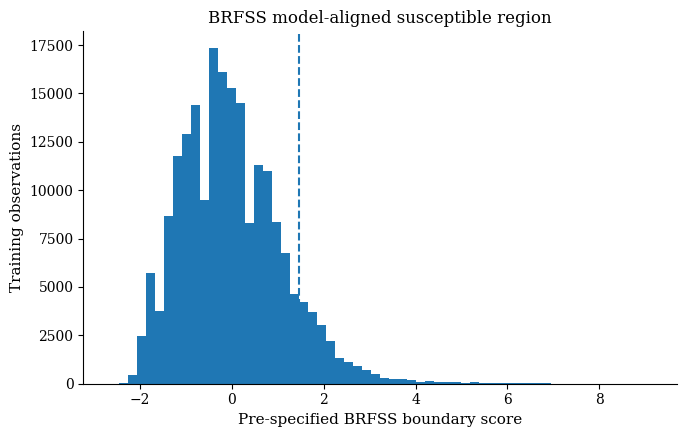

In [7]:
# Safe rerun: this output is redirected to the high-replication Chapter 2 folder.
def make_brfss_model_matrix(train_raw, test_raw):
    core = ["BMI", "GenHlth", "HighBP", "DiffWalk", "Age", "Income"]
    scaler = StandardScaler()
    Ztr = scaler.fit_transform(train_raw[core])
    Zte = scaler.transform(test_raw[core])

    i_bmi = core.index("BMI")
    i_gen = core.index("GenHlth")

    score_tr = (Ztr[:, i_bmi] + Ztr[:, i_gen]) / np.sqrt(2.0)
    contrast_tr = (Ztr[:, i_bmi] - Ztr[:, i_gen]) / np.sqrt(2.0)

    score_te = (Zte[:, i_bmi] + Zte[:, i_gen]) / np.sqrt(2.0)
    contrast_te = (Zte[:, i_bmi] - Zte[:, i_gen]) / np.sqrt(2.0)

    others = ["HighBP", "DiffWalk", "Age", "Income"]
    idx = [core.index(c) for c in others]

    Xtr = np.column_stack([score_tr, contrast_tr, Ztr[:, idx]])
    Xte = np.column_stack([score_te, contrast_te, Zte[:, idx]])

    return Xtr, Xte, ["boundary_score", "BMI_minus_GenHlth", *others], scaler


Xb_model, Xb_model_test, BRFSS_MODEL_FEATURES, brfss_model_scaler = make_brfss_model_matrix(
    Xb_train_raw, Xb_test_raw
)

C_B_TRUE = float(np.quantile(Xb_model[:, 0], 0.90))
region_b = Xb_model[:, 0] > C_B_TRUE

region_summary_b = pd.DataFrame([{
    "region_share": region_b.mean(),
    "recorded_positive_rate_overall": yb_train.mean(),
    "recorded_positive_rate_inside": yb_train[region_b].mean(),
    "eligible_positives": ((yb_train == 1) & region_b).sum(),
    "c_true": C_B_TRUE,
}])

display(region_summary_b)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(Xb_model[:, 0], bins=60)
ax.axvline(C_B_TRUE, linestyle="--", linewidth=1.5)
ax.set_xlabel("Pre-specified BRFSS boundary score")
ax.set_ylabel("Training observations")
ax.set_title("BRFSS model-aligned susceptible region")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_ch2_brfss_susceptible_region.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "fig_ch2_brfss_susceptible_region.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.2a Pre-corruption response-model check

Before any labels are poisoned, the logistic response assumption is checked on
the **same reduced model matrix used by the Bayesian response component**.
Held-out calibration, Brier score and log loss are reported for the linear
logistic model, alongside an untuned histogram gradient-boosting classifier as
a flexible comparator. The purpose is diagnostic: a material flexible-model
advantage would indicate response-model misspecification that should be
considered when interpreting later mechanism recovery.

,dataset,model,auc,brier,log_loss,mean_abs_calibration_bin_gap
0,BRFSS,Logistic,0.807745,0.101971,0.329434,0.015274
1,BRFSS,Flexible HGB,0.814439,0.099645,0.322291,0.003770


BRFSS: flexible-minus-logistic held-out AUC = +0.0067
Interpret this as a response-specification diagnostic, not as a formal goodness-of-fit test.


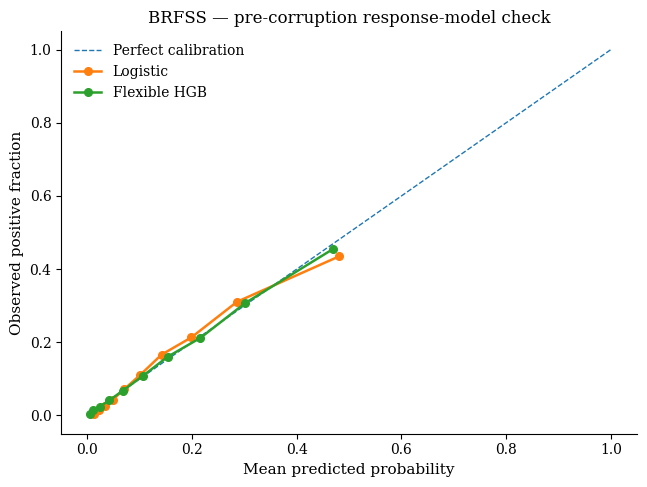

In [8]:
brfss_pre_corruption_check = pre_corruption_response_check(
    X_train=Xb_model,
    y_train=yb_train,
    X_test=Xb_model_test,
    y_test=yb_test,
    dataset_label="BRFSS",
    file_stem="highrep_brfss",
    seed=SEED,
)

## 2.3 Predictive robustness on the full training set

The within-region corruption probability is varied over

\[
q\in\{0.10,0.20,0.35,0.50,0.70\}.
\]

The clean test set remains unchanged. This analysis asks how global predictive discrimination changes as the localised corruption mechanism becomes stronger. The realised number of corruptions and effective global flip rate are reported alongside the nominal \(q\), because only latent positives inside the susceptible region are eligible to flip.

This is a predictive-robustness analysis rather than a direct test of mechanism recovery.


,q,n_corrupted_mean,effective_flip_rate_mean,auc_mean,auc_sd,auc_drop_mean,auc_drop_sd,f1_mean
0,0.10,774.85,0.003818,0.819388,0.000021,0.000243,0.000021,0.441080
1,0.20,1569.70,0.007735,0.818969,0.000026,0.000663,0.000026,0.439823
2,0.35,2720.80,0.013407,0.817991,0.000061,0.001640,0.000061,0.438801
3,0.50,3900.20,0.019218,0.816252,0.000107,0.003379,0.000107,0.436346
4,0.70,5458.45,0.026896,0.812191,0.000135,0.007441,0.000135,0.430873


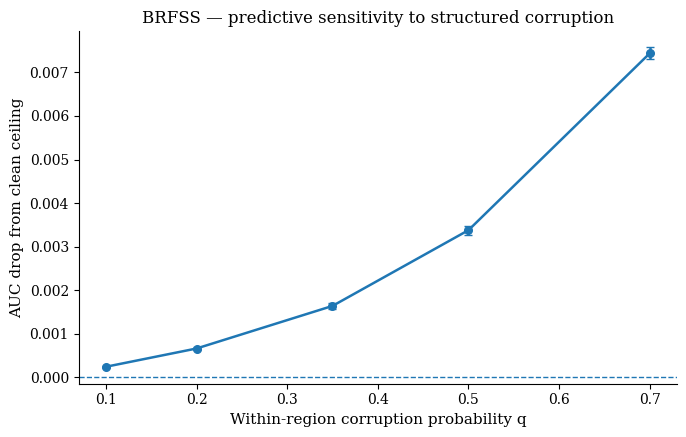

In [9]:
# Safe rerun: this output is redirected to the high-replication Chapter 2 folder.
# Fit each independently generated corruption replicate separately before
# aggregation so between-replicate variability remains visible.
Q_VALUES = [0.10, 0.20, 0.35, 0.50, 0.70]
N_PRED_REPS = 20

predictive_rows = []

for q in Q_VALUES:
    for rep in range(N_PRED_REPS):
        rng = np.random.default_rng(SEED + 1000 + int(q * 1000) + rep)
        y_obs, flips = corrupt_one_sided(yb_train, region_b, q, rng)

        naive = fit_lr(
            Xb_train_z_full, y_obs,
            Xb_test_z_full, yb_test,
            seed=SEED + rep
        )

        predictive_rows.append({
            "q": q,
            "rep": rep,
            "n_corrupted": int(flips.sum()),
            "effective_flip_rate": flips.mean(),
            "auc": naive["auc"],
            "auc_drop": clean_b["auc"] - naive["auc"],
            "f1": naive["f1"],
        })

predictive_b = pd.DataFrame(predictive_rows)

predictive_b_summary = (
    predictive_b
    .groupby("q", as_index=False)
    .agg(
        n_corrupted_mean=("n_corrupted", "mean"),
        effective_flip_rate_mean=("effective_flip_rate", "mean"),
        auc_mean=("auc", "mean"),
        auc_sd=("auc", "std"),
        auc_drop_mean=("auc_drop", "mean"),
        auc_drop_sd=("auc_drop", "std"),
        f1_mean=("f1", "mean"),
    )
)

display(predictive_b_summary)

predictive_b.to_csv(
    RESULT_DIR / "highrep_brfss_predictive_sensitivity_replicates.csv",
    index=False,
)
predictive_b_summary.to_csv(
    RESULT_DIR / "highrep_brfss_predictive_sensitivity_summary.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    predictive_b_summary["q"],
    predictive_b_summary["auc_drop_mean"],
    yerr=predictive_b_summary["auc_drop_sd"],
    marker="o",
    capsize=3,
)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Within-region corruption probability q")
ax.set_ylabel("AUC drop from clean ceiling")
ax.set_title("BRFSS — predictive sensitivity to structured corruption")
plt.tight_layout()
plt.savefig(FIG_DIR / "highrep_fig_ch2_brfss_predictive_sensitivity.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "highrep_fig_ch2_brfss_predictive_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

### Replicate stability check
Running means show whether the reported AUC-drop estimate has settled as independent corruption replicates accumulate.

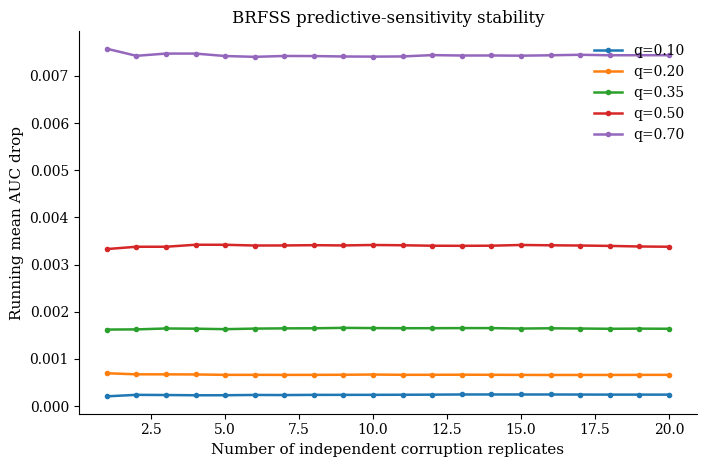

In [10]:

running_parts = []

for q_val, grp in predictive_b.groupby("q"):
    grp = grp.sort_values("rep").copy()
    grp["replicate_count"] = np.arange(1, len(grp) + 1)
    grp["running_mean_auc_drop"] = grp["auc_drop"].expanding().mean()
    running_parts.append(
        grp[["q", "replicate_count", "running_mean_auc_drop"]]
    )

predictive_running = pd.concat(running_parts, ignore_index=True)

predictive_running.to_csv(
    RESULT_DIR / "highrep_brfss_predictive_sensitivity_running_means.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for q_val, grp in predictive_running.groupby("q"):
    ax.plot(
        grp["replicate_count"],
        grp["running_mean_auc_drop"],
        marker="o",
        markersize=3,
        label=f"q={q_val:.2f}",
    )

ax.set_xlabel("Number of independent corruption replicates")
ax.set_ylabel("Running mean AUC drop")
ax.set_title("BRFSS predictive-sensitivity stability")
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "highrep_fig_ch2_brfss_predictive_stability.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "highrep_fig_ch2_brfss_predictive_stability.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 2.4 Matched \(n=6000\) Bayesian sample

The Bayesian analysis uses a reproducible \(n=6000\) sample drawn before corruption and stratified by reference label and region membership. This keeps the realistic BRFSS feature distribution while making HMC computationally proportionate.

In [11]:
idx_bayes_b = stratified_application_sample(
    Xb_model, yb_train, region_b,
    BAYES_N, SEED + 200
)

Xb_bayes = Xb_model[idx_bayes_b]
yb_bayes_true = yb_train[idx_bayes_b]
region_b_bayes = region_b[idx_bayes_b]

yb_bayes_obs, flips_b = corrupt_one_sided(
    yb_bayes_true,
    region_b_bayes,
    Q_APPLIED,
    np.random.default_rng(SEED + 201),
)

display(pd.DataFrame([audit_corruption(
    yb_bayes_true,
    yb_bayes_obs,
    region_b_bayes,
    Q_APPLIED,
    "BRFSS Bayesian sample"
)]))

print("Bayesian feature order:", BRFSS_MODEL_FEATURES)

,dataset,n,q,region_share,eligible_positives,n_corrupted,effective_flip_rate,flips_1_to_0,flips_0_to_1,corruptions_outside_region
0,BRFSS Bayesian sample,6000,0.35,0.096833,231,76,0.012667,76,0,0


Bayesian feature order: ['boundary_score', 'BMI_minus_GenHlth', 'HighBP', 'DiffWalk', 'Age', 'Income']


## 2.5 Confident-learning benchmark

Confident learning is evaluated on the same \(n=6000\) observations, the same observed-negative candidate set and the same precision@\(\,k\) budget used for the Bayesian posterior.

In [12]:
cl_score_b = cleanlab_scores(
    Xb_bayes,
    yb_bayes_obs,
    seed=SEED + 300,
    folds=3,
)

cl_metrics_b = ranking_metrics(
    yb_bayes_obs,
    flips_b,
    cl_score_b,
)

display(pd.DataFrame([{
    "method": "Confident learning",
    **cl_metrics_b
}]))

,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Confident learning,5240,76,0.935114,0.263158


## 2.6 Main BRFSS axis-supplied Bayesian fit

This is the primary applied Bayesian fit. The boundary direction is supplied by the pre-specified risk score; the threshold \(c\), corruption rate \(q\), response coefficients and observation-level posterior corruption probabilities are inferred jointly.

In [13]:
if not STAN_AVAILABLE or not AXIS_STAN.exists():
    raise RuntimeError("Axis Stan model unavailable.")

model_axis = CmdStanModel(stan_file=str(AXIS_STAN))

stan_data_b = {
    "n": len(yb_bayes_obs),
    "p": Xb_bayes.shape[1],
    "X": Xb_bayes.tolist(),
    "y": yb_bayes_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_prior_mean": 0.0,
    "c_prior_sd": 1.5,
}

fit_b_axis = model_axis.sample(
    data=stan_data_b,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 400,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

diag_b_axis, core_b_axis = core_sampler_diagnostics(fit_b_axis)

display(pd.DataFrame([diag_b_axis]))
display(core_b_axis)

22:17:51 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpqc1lj230/tmp5mstx17e.stan to exe file /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/stan/corruption_model_axis_FINAL
22:17:57 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/stan/corruption_model_axis_FINAL
22:17:57 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

22:18:47 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.00168,3584.87,True


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
beta0,-0.956548,0.002361,0.148592,0.145146,-1.196440,-0.958641,-0.707229,3993.42,4842.50,30.4152,1.00031
beta[1],1.538290,0.002687,0.165260,0.162883,1.286120,1.528650,1.819770,3901.31,4906.16,29.7136,1.00041
beta[2],-0.033069,0.001256,0.118745,0.117550,-0.231434,-0.031845,0.159201,8996.52,5854.84,68.5204,1.00061
beta[3],0.547815,0.000900,0.082575,0.082080,0.410140,0.548494,0.682234,8446.90,5682.33,64.3343,1.00030
beta[4],0.233437,0.001279,0.108848,0.106899,0.066484,0.226922,0.420740,7506.18,5104.28,57.1695,1.00007
beta[5],0.937793,0.001468,0.110859,0.111541,0.761636,0.933433,1.125930,5819.12,5267.91,44.3203,1.00020
beta[6],-0.331949,0.001165,0.095732,0.095177,-0.495457,-0.328934,-0.181349,6823.63,4985.88,51.9709,1.00083
c,-2.268870,0.010053,0.621712,0.475690,-3.482300,-2.107630,-1.560870,5115.44,4016.27,38.9608,1.00168
q,0.657965,0.000354,0.020970,0.020543,0.621684,0.659360,0.689802,3584.87,4272.94,27.3035,1.00087


,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,c,1.461407,-2.268871,-3.869136,-1.477872
1,q,0.350000,0.657965,0.613025,0.695114


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Bayesian posterior,5240,76,0.950387,0.263158
1,Confident learning,5240,76,0.935114,0.263158


Mean posterior corruption probability — injected corruptions: 0.9019806750715278
Mean posterior corruption probability — clean observed negatives: 0.27109170502975843


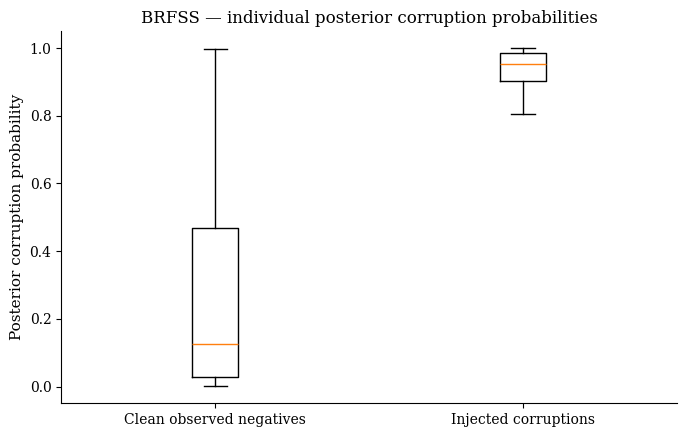

In [14]:
# Safe rerun: this output is redirected to the high-replication Chapter 2 folder.
c_draw = fit_b_axis.stan_variable("c")
q_draw = fit_b_axis.stan_variable("q")
z_b = fit_b_axis.stan_variable("z_prob").mean(axis=0)

bayes_metrics_b = ranking_metrics(
    yb_bayes_obs,
    flips_b,
    z_b,
)

parameter_summary_b = pd.DataFrame([
    {
        "parameter": "c",
        "true": C_B_TRUE,
        "posterior_mean": c_draw.mean(),
        "ci_2.5": np.quantile(c_draw, 0.025),
        "ci_97.5": np.quantile(c_draw, 0.975),
    },
    {
        "parameter": "q",
        "true": Q_APPLIED,
        "posterior_mean": q_draw.mean(),
        "ci_2.5": np.quantile(q_draw, 0.025),
        "ci_97.5": np.quantile(q_draw, 0.975),
    },
])

comparison_b = pd.DataFrame([
    {"method": "Bayesian posterior", **bayes_metrics_b},
    {"method": "Confident learning", **cl_metrics_b},
])

display(parameter_summary_b)
display(comparison_b)

neg_b = yb_bayes_obs == 0

print(
    "Mean posterior corruption probability — injected corruptions:",
    z_b[flips_b].mean()
)
print(
    "Mean posterior corruption probability — clean observed negatives:",
    z_b[neg_b & ~flips_b].mean()
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot(
    [
        z_b[neg_b & ~flips_b],
        z_b[flips_b],
    ],
    labels=[
        "Clean observed negatives",
        "Injected corruptions",
    ],
    showfliers=False,
)
ax.set_ylabel("Posterior corruption probability")
ax.set_title("BRFSS — individual posterior corruption probabilities")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_posterior_corruption_probabilities.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_posterior_corruption_probabilities.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Main-fit interpretation

The main BRFSS fit should be interpreted along two axes:

- **localisation:** how well posterior corruption probabilities rank the injected corruptions;
- **mechanism recovery:** whether \(c\) and \(q\) recover their known semi-synthetic values.

A well-converged posterior does not by itself imply that the corruption mechanism is correctly recovered. The following diagnostics are included to determine why mechanism recovery may deteriorate on real labels.

## 2.6a Response-versus-geometry diagnostic

The main BRFSS fit converges but estimates a threshold far below the generating
threshold. This diagnostic asks whether the fitted susceptible region has expanded
to cover most observations and whether the posterior corruption ranking is therefore
largely inherited from the fitted latent-response probabilities.

The response-only score is the posterior mean of
\(p_i=\operatorname{logit}^{-1}(\beta_0+x_i^\top\beta)\), averaged across posterior
draws. It is evaluated on exactly the same observed-negative candidates as the Bayesian
posterior and confident-learning rankings.


In [15]:
def posterior_mean_response_probability(fit, X, batch_size=250):
    """Average logistic response probabilities across posterior draws.

    This averages probabilities draw by draw rather than evaluating the
    logistic function at posterior-mean coefficients.
    """
    beta0_draws = np.asarray(fit.stan_variable("beta0")).reshape(-1)
    beta_draws = np.asarray(fit.stan_variable("beta"))

    if beta_draws.ndim != 2:
        raise ValueError(
            f"Expected beta draws with shape (draws, p); got {beta_draws.shape}."
        )
    if beta_draws.shape[1] != X.shape[1]:
        raise ValueError(
            f"Feature mismatch: beta has {beta_draws.shape[1]} columns, "
            f"but X has {X.shape[1]}."
        )

    probability_sum = np.zeros(X.shape[0], dtype=float)

    for start in range(0, len(beta0_draws), batch_size):
        stop = min(start + batch_size, len(beta0_draws))
        logits = (
            beta0_draws[start:stop, None]
            + beta_draws[start:stop] @ X.T
        )
        probability_sum += sigmoid(
            np.clip(logits, -40.0, 40.0)
        ).sum(axis=0)

    return probability_sum / len(beta0_draws)


# Fitted soft-region membership under the posterior-mean threshold.
c_hat_b = float(c_draw.mean())
r_fitted_b = sigmoid(
    KAPPA * (Xb_bayes[:, 0] - c_hat_b)
)

# Posterior-mean latent-response probability, averaged over draws.
p_hat_b = posterior_mean_response_probability(
    fit_b_axis,
    Xb_bayes,
)

response_only_metrics_b = ranking_metrics(
    yb_bayes_obs,
    flips_b,
    p_hat_b,
)

brfss_response_geometry = pd.DataFrame([{
    "c_true": C_B_TRUE,
    "c_hat": c_hat_b,
    "boundary_score_min": float(Xb_bayes[:, 0].min()),
    "mean_fitted_membership": float(r_fitted_b.mean()),
    "share_membership_gt_0.5": float(np.mean(r_fitted_b > 0.5)),
    "share_membership_gt_0.9": float(np.mean(r_fitted_b > 0.9)),
}])

brfss_ranking_comparison = pd.DataFrame([
    {"method": "Bayesian posterior", **bayes_metrics_b},
    {"method": "Response probability only", **response_only_metrics_b},
    {"method": "Confident learning", **cl_metrics_b},
])

display(brfss_response_geometry)
display(brfss_ranking_comparison)

print(
    "AUC difference, Bayesian posterior minus response-only:",
    bayes_metrics_b["ranked_auc"]
    - response_only_metrics_b["ranked_auc"],
)


,c_true,c_hat,boundary_score_min,mean_fitted_membership,share_membership_gt_0.5,share_membership_gt_0.9
0,1.461407,-2.268871,-2.327101,0.993963,0.999833,0.9875


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Bayesian posterior,5240,76,0.950387,0.263158
1,Response probability only,5240,76,0.950343,0.263158
2,Confident learning,5240,76,0.935114,0.263158


AUC difference, Bayesian posterior minus response-only: 4.331607485008604e-05


## 2.7 Diagnostic A — verify region alignment and soft-boundary approximation

In [16]:
check = pd.DataFrame({
    "boundary_score": Xb_bayes[:, 0],
    "inside_region_from_score": Xb_bayes[:, 0] > C_B_TRUE,
    "inside_region_used_for_corruption": region_b_bayes,
})

mismatch_count = (
    check["inside_region_from_score"]
    != check["inside_region_used_for_corruption"]
).sum()

print("Mismatch count:", mismatch_count)
print(check["boundary_score"].describe())
print("c_true =", C_B_TRUE)

r_true_soft = sigmoid(
    KAPPA * (Xb_bayes[:, 0] - C_B_TRUE)
)

print("Mean soft membership overall:", r_true_soft.mean())
print(
    "Mean soft membership inside hard region:",
    r_true_soft[region_b_bayes].mean()
)
print(
    "Mean soft membership outside hard region:",
    r_true_soft[~region_b_bayes].mean()
)
print(
    "Proportion within 0.2 of boundary:",
    np.mean(np.abs(Xb_bayes[:, 0] - C_B_TRUE) < 0.2)
)

Mismatch count: 0
count    6000.000000
mean       -0.007747
std         1.091435
min        -2.327101
25%        -0.807926
50%        -0.146073
75%         0.622944
max         6.000073
Name: boundary_score, dtype: float64
c_true = 1.461407312209662
Mean soft membership overall: 0.10414249566616587
Mean soft membership inside hard region: 0.8542937197408458
Mean soft membership outside hard region: 0.02371476708388333
Proportion within 0.2 of boundary: 0.05


## 2.8 Diagnostic B — fix the true threshold and re-estimate \(q\)

This diagnostic asks whether the poor \(q\) estimate is explained primarily by compensation between the threshold \(c\) and corruption rate \(q\).

It uses a separate temporary Stan model with the true threshold fixed. The frozen Chapter 0 model is not modified.

In [17]:
fixed_c_stan = r"""
data {
  int<lower=1> n;
  int<lower=1> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;

  int<lower=1, upper=p> boundary_dim;
  real<lower=0> kappa;
  real c_fixed;
}

parameters {
  real beta0;
  vector[p] beta;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, 2);
  beta ~ normal(0, 1);
  q ~ beta(2, 5);

  for (i in 1:n) {
    real p_true = inv_logit(
      beta0 + dot_product(beta, X[i])
    );
    real r = inv_logit(
      kappa * (
        X[i, boundary_dim] - c_fixed
      )
    );
    real w = q * r;

    if (y[i] == 1) {
      target += log(p_true) + log1m(w);
    } else {
      target += log_sum_exp(
        log1m(p_true),
        log(p_true) + log(w)
      );
    }
  }
}
"""

fixed_c_path = STAN_DIR / "corruption_model_axis_FIXED_C_DIAGNOSTIC.stan"

fixed_c_path.write_text(fixed_c_stan)

fixed_c_model = CmdStanModel(
    stan_file=str(fixed_c_path)
)

fixed_c_data = {
    "n": len(yb_bayes_obs),
    "p": Xb_bayes.shape[1],
    "X": Xb_bayes.tolist(),
    "y": yb_bayes_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_fixed": C_B_TRUE,
}

fit_b_fixed_c = fixed_c_model.sample(
    data=fixed_c_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 450,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

diag_fixed_c, core_fixed_c = core_sampler_diagnostics(
    fit_b_fixed_c
)

display(pd.DataFrame([diag_fixed_c]))

q_fixed_c = fit_b_fixed_c.stan_variable("q")

fixed_c_summary = pd.DataFrame([{
    "parameter": "q",
    "true": Q_APPLIED,
    "posterior_mean": q_fixed_c.mean(),
    "ci_2.5": np.quantile(q_fixed_c, 0.025),
    "ci_97.5": np.quantile(q_fixed_c, 0.975),
}])

display(fixed_c_summary)

22:20:28 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpkexeumbc/tmpra5vekcs.stan to exe file /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/stan/corruption_model_axis_FIXED_C_DIAGNOSTIC
22:20:32 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/stan/corruption_model_axis_FIXED_C_DIAGNOSTIC
22:20:32 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

22:21:04 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.00095,6389.05,True


,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,q,0.35,0.587846,0.500629,0.663618


## 2.8a Diagnostic B$'$ — does the likelihood genuinely prefer the collapsed threshold?

Dissertation target: replaces the "remains an open question" sentence in
Section 5.1 (TODO slot). Compares the main axis-supplied fit (threshold
estimated; collapses to $-2.269$) against the fixed-$c$ diagnostic (threshold
held at the generating value) on the same data and likelihood. The fixed-$c$
model emits no `log_lik`, so pointwise likelihood is computed here directly,
replicating the Stan marginal likelihood.


In [18]:
# Diagnostic B': likelihood comparison, collapsed vs fixed threshold.
# Uses fit_b_axis (c estimated) and fit_b_fixed_c (c = C_B_TRUE) on the
# identical BRFSS Bayesian sample. boundary_dim = 1 -> numpy column 0.

from scipy.special import expit

BOUND_COL = 0
X_cmp = np.asarray(Xb_bayes, float)
y_cmp = np.asarray(yb_bayes_obs, int)

def axis_total_loglik(beta0, beta, c, q, X, y, kappa=KAPPA, bcol=BOUND_COL):
    """One-sided marginal log-likelihood of the axis-supplied model."""
    pr = expit(beta0 + X @ np.asarray(beta, float))
    r = expit(kappa * (X[:, bcol] - c))
    w = q * r
    lik = np.where(y == 1, (1.0 - w) * pr, (1.0 - pr) + w * pr)
    return float(np.log(np.clip(lik, 1e-300, None)).sum())

def _post_mean_params(fit, c_value=None):
    beta0 = float(np.asarray(fit.stan_variable("beta0")).mean())
    beta = np.asarray(fit.stan_variable("beta")).mean(axis=0)
    q = float(np.asarray(fit.stan_variable("q")).mean())
    c = float(np.asarray(fit.stan_variable("c")).mean()) if c_value is None \
        else float(c_value)
    return beta0, beta, c, q

# ---- 1. plug-in comparison at posterior means ----
b0_m, be_m, c_m, q_m = _post_mean_params(fit_b_axis)
b0_f, be_f, c_f, q_f = _post_mean_params(fit_b_fixed_c, c_value=C_B_TRUE)

ll_main = axis_total_loglik(b0_m, be_m, c_m, q_m, X_cmp, y_cmp)
ll_fixed = axis_total_loglik(b0_f, be_f, c_f, q_f, X_cmp, y_cmp)

# ---- 2. posterior-averaged total log-likelihood (thinned draws) ----
def _posterior_avg_loglik(fit, c_value=None, thin=8):
    b0_d = np.asarray(fit.stan_variable("beta0"))[::thin]
    be_d = np.asarray(fit.stan_variable("beta"))[::thin]
    q_d = np.asarray(fit.stan_variable("q"))[::thin]
    if c_value is None:
        c_d = np.asarray(fit.stan_variable("c"))[::thin]
    else:
        c_d = np.full(len(q_d), float(c_value))
    tot = np.empty(len(q_d))
    for i in range(len(q_d)):
        tot[i] = axis_total_loglik(
            float(b0_d[i]), be_d[i], float(c_d[i]), float(q_d[i]),
            X_cmp, y_cmp,
        )
    return float(tot.mean()), len(q_d)

avg_main, nd_m = _posterior_avg_loglik(fit_b_axis)
avg_fixed, nd_f = _posterior_avg_loglik(fit_b_fixed_c, c_value=C_B_TRUE)

collapse_cmp = pd.DataFrame([
    {"fit": "main (c estimated)", "c": round(c_m, 3), "q": round(q_m, 3),
     "loglik_at_post_mean": round(ll_main, 2),
     "posterior_avg_loglik": round(avg_main, 2), "draws_used": nd_m},
    {"fit": "fixed-c diagnostic", "c": round(c_f, 3), "q": round(q_f, 3),
     "loglik_at_post_mean": round(ll_fixed, 2),
     "posterior_avg_loglik": round(avg_fixed, 2), "draws_used": nd_f},
])
display(collapse_cmp)

gap_plug = ll_main - ll_fixed
gap_avg = avg_main - avg_fixed
print(f"Plug-in gap (main - fixed):            {gap_plug:+.2f} "
      f"({gap_plug / len(y_cmp):+.5f} per observation)")
print(f"Posterior-averaged gap (main - fixed): {gap_avg:+.2f}")
print()
print("Reading the result:")
print("  * Both gaps clearly positive and non-trivial in magnitude ->")
print("    the collapse is the likelihood's genuine preference: the model")
print("    trades region geometry for a global corruption term when the")
print("    response model cannot represent the recorded relationship.")
print("    (Caveat for the write-up: the fixed-c model is nested within")
print("    the main model, so some preference for the freer model is")
print("    expected; the evidential content is the MAGNITUDE of the gap,")
print("    not its sign alone.)")
print("  * Gaps near zero or negative -> the collapse is NOT a clear")
print("    likelihood preference; keep the 'open question' framing in")
print("    Section 5.1 and do not strengthen the claim.")


,fit,c,q,loglik_at_post_mean,posterior_avg_loglik,draws_used
0,main (c estimated),-2.269,0.658,-1885.28,-1889.31,1000
1,fixed-c diagnostic,1.461,0.588,-1892.61,-1896.63,1000


Plug-in gap (main - fixed):            +7.33 (+0.00122 per observation)
Posterior-averaged gap (main - fixed): +7.33

Reading the result:
  * Both gaps clearly positive and non-trivial in magnitude ->
    the collapse is the likelihood's genuine preference: the model
    trades region geometry for a global corruption term when the
    response model cannot represent the recorded relationship.
    (Caveat for the write-up: the fixed-c model is nested within
    the main model, so some preference for the freer model is
    expected; the evidential content is the MAGNITUDE of the gap,
    not its sign alone.)
  * Gaps near zero or negative -> the collapse is NOT a clear
    likelihood preference; keep the 'open question' framing in
    Section 5.1 and do not strengthen the claim.


## 2.9 Diagnostic C — realistic \(X\), model-correct logistic \(Y\)

This diagnostic separates realistic covariate structure from response-model specification.

The realistic BRFSS covariates are held fixed, but a new latent response is generated from a logistic model of exactly the form assumed by Stan. The same susceptible region and \(q=0.35\) are then used to inject one-sided corruption.

If recovery of \(c\) and \(q\) improves substantially here relative to the real-label fit, realistic covariate geometry alone is not sufficient to explain the earlier difficulty. The comparison instead provides evidence that mismatch between the logistic latent-response model and the recorded BRFSS response relationship contributes to response–corruption confounding. Because this is a diagnostic comparison rather than a formal decomposition, it is not used to claim that response misspecification is the only possible cause.


In [19]:
rng_diag = np.random.default_rng(SEED + 800)

lr_diag = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    random_state=SEED,
)

lr_diag.fit(
    Xb_bayes,
    yb_bayes_true,
)

beta0_diag = float(
    lr_diag.intercept_[0]
)
beta_diag = lr_diag.coef_[0].copy()

eta_diag = (
    beta0_diag
    + Xb_bayes @ beta_diag
)

p_diag = sigmoid(eta_diag)

y_diag_true = rng_diag.binomial(
    1,
    p_diag,
)

y_diag_obs, flips_diag = corrupt_one_sided(
    y_diag_true,
    region_b_bayes,
    Q_APPLIED,
    rng_diag,
)

print("n =", len(y_diag_true))
print(
    "Latent positive prevalence:",
    y_diag_true.mean()
)
print(
    "Region share:",
    region_b_bayes.mean()
)
print(
    "Eligible positives:",
    (
        (y_diag_true == 1)
        & region_b_bayes
    ).sum()
)
print(
    "Injected corruptions:",
    flips_diag.sum()
)
print(
    "Effective corruption rate:",
    flips_diag.mean()
)

print("\nTrue beta0:", beta0_diag)
print("True beta:", beta_diag)
print("True c:", C_B_TRUE)
print("True q:", Q_APPLIED)

n = 6000
Latent positive prevalence: 0.1425
Region share: 0.09683333333333333
Eligible positives: 263
Injected corruptions: 87
Effective corruption rate: 0.0145

True beta0: -2.358715549161293
True beta: [ 0.75839951 -0.10166474  0.41301221  0.03656521  0.46711448 -0.10941284]
True c: 1.461407312209662
True q: 0.35


In [20]:
stan_data_diag = {
    "n": len(y_diag_obs),
    "p": Xb_bayes.shape[1],
    "X": Xb_bayes.tolist(),
    "y": y_diag_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_prior_mean": 0.0,
    "c_prior_sd": 1.5,
}

fit_b_model_correct = model_axis.sample(
    data=stan_data_diag,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 801,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

diag_model_correct, core_model_correct = core_sampler_diagnostics(
    fit_b_model_correct
)

display(
    pd.DataFrame([
        diag_model_correct
    ])
)

22:21:04 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

22:21:59 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.00113,7282.31,True


In [21]:
c_mc = fit_b_model_correct.stan_variable("c")
q_mc = fit_b_model_correct.stan_variable("q")
beta0_mc = fit_b_model_correct.stan_variable("beta0")
beta_mc = fit_b_model_correct.stan_variable("beta")

recovery_mc = pd.DataFrame([
    {
        "parameter": "beta0",
        "true": beta0_diag,
        "posterior_mean": beta0_mc.mean(),
        "ci_2.5": np.quantile(beta0_mc, 0.025),
        "ci_97.5": np.quantile(beta0_mc, 0.975),
    },
    {
        "parameter": "c",
        "true": C_B_TRUE,
        "posterior_mean": c_mc.mean(),
        "ci_2.5": np.quantile(c_mc, 0.025),
        "ci_97.5": np.quantile(c_mc, 0.975),
    },
    {
        "parameter": "q",
        "true": Q_APPLIED,
        "posterior_mean": q_mc.mean(),
        "ci_2.5": np.quantile(q_mc, 0.025),
        "ci_97.5": np.quantile(q_mc, 0.975),
    },
])

display(recovery_mc)

beta_recovery_mc = pd.DataFrame({
    "parameter": [
        f"beta[{j}]"
        for j in range(
            1,
            len(beta_diag) + 1
        )
    ],
    "true": beta_diag,
    "posterior_mean": beta_mc.mean(axis=0),
    "ci_2.5": np.quantile(
        beta_mc,
        0.025,
        axis=0
    ),
    "ci_97.5": np.quantile(
        beta_mc,
        0.975,
        axis=0
    ),
})

display(beta_recovery_mc)

,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,beta0,-2.358716,-2.389131,-2.501653,-2.279226
1,c,1.461407,1.655554,1.265581,2.081054
2,q,0.350000,0.340386,0.185664,0.472351


,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,beta[1],0.758400,0.812294,0.681514,0.945964
1,beta[2],-0.101665,-0.174716,-0.272498,-0.074474
2,beta[3],0.413012,0.419220,0.327346,0.511196
3,beta[4],0.036565,0.073415,-0.007326,0.151454
4,beta[5],0.467114,0.464446,0.359583,0.572529
5,beta[6],-0.109413,-0.030789,-0.120267,0.059591


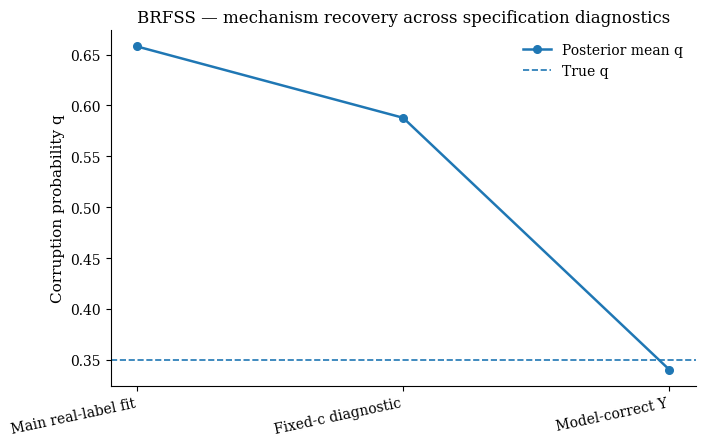

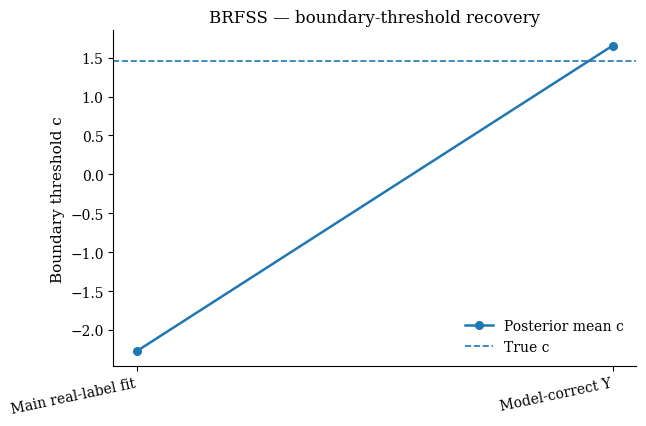

In [22]:
# Safe rerun: this output is redirected to the high-replication Chapter 2 folder.
# Compact visual summary of the BRFSS mechanism-recovery diagnostics.
# The main fit estimates both c and q; the fixed-c diagnostic estimates q only;
# the model-correct-Y diagnostic again estimates both c and q.

recovery_plot = pd.DataFrame([
    {
        "fit": "Main real-label fit",
        "c_estimate": float(c_draw.mean()),
        "q_estimate": float(q_draw.mean()),
    },
    {
        "fit": "Fixed-c diagnostic",
        "c_estimate": np.nan,
        "q_estimate": float(q_fixed_c.mean()),
    },
    {
        "fit": "Model-correct Y",
        "c_estimate": float(c_mc.mean()),
        "q_estimate": float(q_mc.mean()),
    },
])

fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(len(recovery_plot))

ax.plot(
    x,
    recovery_plot["q_estimate"],
    marker="o",
    label="Posterior mean q",
)
ax.axhline(
    Q_APPLIED,
    linestyle="--",
    linewidth=1.2,
    label="True q",
)
ax.set_xticks(x)
ax.set_xticklabels(recovery_plot["fit"], rotation=12, ha="right")
ax.set_ylabel("Corruption probability q")
ax.set_title("BRFSS — mechanism recovery across specification diagnostics")
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_recovery_diagnostics.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_recovery_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Threshold recovery is shown separately because c and q are on different scales.
fig, ax = plt.subplots(figsize=(6.6, 4.4))
c_names = ["Main real-label fit", "Model-correct Y"]
c_estimates = [float(c_draw.mean()), float(c_mc.mean())]
ax.plot(
    np.arange(len(c_names)),
    c_estimates,
    marker="o",
    label="Posterior mean c",
)
ax.axhline(
    C_B_TRUE,
    linestyle="--",
    linewidth=1.2,
    label="True c",
)
ax.set_xticks(np.arange(len(c_names)))
ax.set_xticklabels(c_names, rotation=12, ha="right")
ax.set_ylabel("Boundary threshold c")
ax.set_title("BRFSS — boundary-threshold recovery")
ax.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_threshold_recovery.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "fig_ch2_brfss_threshold_recovery.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Specification diagnostic interpretation

The three BRFSS fits answer different questions:

1. **Main real-label fit:** can the model recover the injected corruption mechanism when both the covariates and the recorded response relationship are realistic?
2. **Fixed-\(c\) fit:** how much of any error in \(q\) can be reduced when threshold uncertainty is removed?
3. **Model-correct-\(Y\) fit:** how does recovery change when the same realistic \(X\) is paired with a response generated from the fitted model class?

Together these form the simulation-to-application bridge. They distinguish posterior convergence from scientific recovery and help diagnose, without over-identifying, the source of any applied recovery failure.


## 2.10 Individual posterior uncertainty

The following table is a semi-synthetic validation device. It does not identify naturally undiagnosed BRFSS respondents. It asks whether, under known injected corruption, the posterior assigns high corruption probability to observations that were actually altered.

In [23]:
candidate_idx_b = np.flatnonzero(
    yb_bayes_obs == 0
)

rank_idx = candidate_idx_b[
    np.argsort(
        z_b[candidate_idx_b]
    )[::-1][:20]
]

top_b = Xb_train_raw.iloc[
    idx_bayes_b[rank_idx]
][
    [
        "BMI",
        "GenHlth",
        "Age",
        "HighBP",
        "DiffWalk",
        "Income",
    ]
].copy()

top_b.insert(
    0,
    "posterior_corruption_prob",
    z_b[rank_idx]
)

top_b.insert(
    1,
    "observed_label",
    yb_bayes_obs[rank_idx]
)

top_b.insert(
    2,
    "reference_label",
    yb_bayes_true[rank_idx]
)

top_b.insert(
    3,
    "injected_corruption",
    flips_b[rank_idx]
)

top_b.insert(
    4,
    "inside_true_region",
    region_b_bayes[rank_idx]
)

display(
    top_b.reset_index(drop=True)
)

,posterior_corruption_prob,observed_label,reference_label,injected_corruption,inside_true_region,BMI,GenHlth,Age,HighBP,DiffWalk,Income
0,0.999314,0,1,True,True,51.0,5.0,11.0,1.0,1.0,1.0
1,0.998639,0,1,True,True,54.0,4.0,11.0,1.0,1.0,2.0
2,0.998360,0,0,False,True,51.0,5.0,9.0,1.0,1.0,3.0
3,0.998339,0,1,True,True,55.0,5.0,6.0,1.0,1.0,1.0
4,0.998255,0,0,False,True,69.0,5.0,1.0,1.0,0.0,1.0
5,0.997821,0,1,True,True,63.0,4.0,5.0,1.0,1.0,2.0
6,0.997783,0,0,False,True,53.0,5.0,6.0,1.0,1.0,1.0
7,0.997450,0,1,True,True,45.0,5.0,11.0,1.0,1.0,4.0
8,0.996052,0,1,True,True,45.0,5.0,9.0,1.0,1.0,3.0
9,0.996024,0,1,True,True,41.0,5.0,11.0,1.0,1.0,3.0


## 2.11 General-boundary BRFSS stress test

Chapter 1 Experiment 4 showed that learning $\alpha$ can produce competing posterior modes. The same BRFSS sample is therefore fitted with the general model as a stress test.

The true semi-synthetic region is the first axis of the transformed feature matrix, so

$
\alpha_{\text{true}}=(1,0,\ldots,0).
$

The learned direction is interpreted only if the fit passes the same diagnostic criteria used in Chapter 1. Diagnostic failure is itself an applied result.

In [24]:
RUN_GENERAL_BRFSS = True

if RUN_GENERAL_BRFSS:
    if not GENERAL_STAN.exists():
        raise FileNotFoundError(
            f"Missing {GENERAL_STAN}"
        )

    model_general = CmdStanModel(
        stan_file=str(GENERAL_STAN)
    )

    data_general_b = {
        "n": len(yb_bayes_obs),
        "p": Xb_bayes.shape[1],
        "X": Xb_bayes.tolist(),
        "y": yb_bayes_obs.astype(int).tolist(),
        "kappa": KAPPA,
        "c_prior_mean": 0.0,
        "c_prior_sd": 1.5,
    }

    fit_b_general = model_general.sample(
        data=data_general_b,
        chains=4,
        parallel_chains=4,
        iter_warmup=1000,
        iter_sampling=2000,
        seed=SEED + 500,
        adapt_delta=0.99,
        max_treedepth=12,
        show_progress=True,
    )

    diag_b_general, core_b_general = core_sampler_diagnostics(
        fit_b_general
    )

    display(
        pd.DataFrame([
            diag_b_general
        ])
    )

    display(
        core_b_general
    )

    if diag_b_general["converged"]:
        alpha_draw = fit_b_general.stan_variable(
            "alpha"
        )

        alpha_true_b = np.zeros(
            Xb_bayes.shape[1]
        )
        alpha_true_b[0] = 1.0

        cosine = (
            alpha_draw
            @ alpha_true_b
        )

        z_bg = fit_b_general.stan_variable(
            "z_prob"
        ).mean(axis=0)

        general_metrics_b = ranking_metrics(
            yb_bayes_obs,
            flips_b,
            z_bg,
        )

        print(
            "Mean cosine similarity:",
            cosine.mean()
        )
        print(
            "5th percentile cosine similarity:",
            np.quantile(
                cosine,
                0.05
            )
        )

        display(
            pd.DataFrame([{
                "method": "General Bayesian posterior",
                **general_metrics_b
            }])
        )
    else:
        print(
            "GENERAL FIT NOT INTERPRETED:"
            " diagnostics did not pass."
        )

22:23:41 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmp9z5y77ez/tmpiwecly9m.stan to exe file /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/stan/corruption_model_general_FINAL
22:23:46 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/final_project_folder copy/high_replication/chapter2/stan/corruption_model_general_FINAL
22:23:46 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

22:29:34 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.03748,114.167,True


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
beta0,-1.051420,0.021029,0.233750,0.193177,-1.470230,-1.020700,-0.731679,170.296,221.740,0.210244,1.02030
beta[1],1.531720,0.007833,0.171196,0.173282,1.262130,1.525030,1.819530,521.012,1970.640,0.643228,1.01125
beta[2],-0.037383,0.001643,0.124814,0.124252,-0.243741,-0.037988,0.168563,5788.260,4953.530,7.146030,1.00168
beta[3],0.612189,0.019049,0.172074,0.117245,0.405059,0.568922,0.979822,114.167,279.624,0.140948,1.03748
beta[4],0.250631,0.006244,0.129406,0.120373,0.056994,0.241792,0.476565,516.345,803.331,0.637466,1.00403
beta[5],0.966495,0.003801,0.125252,0.120748,0.771892,0.960995,1.179370,1193.670,3141.790,1.473670,1.00623
beta[6],-0.350372,0.008495,0.125836,0.119784,-0.578179,-0.341910,-0.163114,260.810,440.635,0.321989,1.01269
c,-2.225120,0.105683,1.105420,1.017880,-4.016850,-2.271500,-0.482566,131.297,204.952,0.162096,1.02690
q,0.657883,0.000400,0.021281,0.020776,0.621768,0.658983,0.690616,2971.530,4588.940,3.668570,1.00268
alpha[1],0.389233,0.006512,0.304578,0.256876,-0.226287,0.451185,0.799259,2712.850,3354.710,3.349220,1.00878


Mean cosine similarity: 0.38923259263601756
5th percentile cosine similarity: -0.22628684149999997


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,General Bayesian posterior,5240,76,0.948185,0.263158


# 3. Credit default replication

The credit dataset provides a second-domain test of whether the conclusions depend on the healthcare feature distribution.

The same principles are retained:

- clean train/test split before corruption;
- one-sided $1\to0$ corruption;
- a pre-specified halfspace;
- matched Bayesian/Cleanlab localisation metrics;
- interpretation of mechanism recovery only when sampler diagnostics are satisfactory.

## 3.1 Data and clean ceiling

In [25]:
if not CREDIT_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CREDIT_PATH}"
    )

credit = pd.read_csv(
    CREDIT_PATH
)

if "ID" in credit.columns:
    credit = credit.drop(
        columns=["ID"]
    )

if "default.payment.next.month" in credit.columns:
    credit = credit.rename(
        columns={
            "default.payment.next.month":
            "default"
        }
    )

TARGET_C = "default"

yc = credit[TARGET_C].to_numpy(
    dtype=int
)

Xc_raw = credit.drop(
    columns=[TARGET_C]
).copy()

Xc_train_raw, Xc_test_raw, yc_train, yc_test = train_test_split(
    Xc_raw,
    yc,
    test_size=0.20,
    stratify=yc,
    random_state=SEED,
)

Xc_train_raw = Xc_train_raw.reset_index(
    drop=True
)
Xc_test_raw = Xc_test_raw.reset_index(
    drop=True
)

scaler_c_full = StandardScaler()

Xc_train_z_full = scaler_c_full.fit_transform(
    Xc_train_raw
)
Xc_test_z_full = scaler_c_full.transform(
    Xc_test_raw
)

clean_c = fit_lr(
    Xc_train_z_full,
    yc_train,
    Xc_test_z_full,
    yc_test,
)

print(
    f"Credit rows: {len(credit):,}"
)
print(
    f"Recorded default prevalence: {yc.mean():.3%}"
)
print(
    f"Clean LR AUC: {clean_c['auc']:.4f}"
)
print(
    f"Clean LR F1:  {clean_c['f1']:.4f}"
)

Credit rows: 30,000
Recorded default prevalence: 22.120%
Clean LR AUC: 0.7081
Clean LR F1:  0.4613


## 3.2 Model-aligned distress region

The distress direction combines repayment delay (`PAY_0`, larger is worse) and available credit (`LIMIT_BAL`, smaller is worse). An orthogonal contrast retains the linear information in the two original variables.

In [26]:
def make_credit_model_matrix(
    train_raw,
    test_raw
):
    required = [
        "PAY_0",
        "LIMIT_BAL",
        "AGE",
        "PAY_2",
        "BILL_AMT1",
        "PAY_AMT1",
    ]

    missing = [
        c for c in required
        if c not in train_raw.columns
    ]

    if missing:
        raise KeyError(
            f"Missing expected credit columns: {missing}"
        )

    scaler = StandardScaler()

    Ztr = scaler.fit_transform(
        train_raw[required]
    )
    Zte = scaler.transform(
        test_raw[required]
    )

    i_pay = required.index(
        "PAY_0"
    )
    i_lim = required.index(
        "LIMIT_BAL"
    )

    score_tr = (
        Ztr[:, i_pay]
        - Ztr[:, i_lim]
    ) / np.sqrt(2.0)

    contrast_tr = (
        Ztr[:, i_pay]
        + Ztr[:, i_lim]
    ) / np.sqrt(2.0)

    score_te = (
        Zte[:, i_pay]
        - Zte[:, i_lim]
    ) / np.sqrt(2.0)

    contrast_te = (
        Zte[:, i_pay]
        + Zte[:, i_lim]
    ) / np.sqrt(2.0)

    others = [
        "AGE",
        "PAY_2",
        "BILL_AMT1",
        "PAY_AMT1",
    ]

    idx = [
        required.index(c)
        for c in others
    ]

    Xtr = np.column_stack([
        score_tr,
        contrast_tr,
        Ztr[:, idx],
    ])

    Xte = np.column_stack([
        score_te,
        contrast_te,
        Zte[:, idx],
    ])

    return (
        Xtr,
        Xte,
        [
            "boundary_score",
            "PAY0_plus_LIMITBAL_contrast",
            *others,
        ],
        scaler,
    )


Xc_model, Xc_model_test, CREDIT_MODEL_FEATURES, credit_model_scaler = make_credit_model_matrix(
    Xc_train_raw,
    Xc_test_raw,
)

C_C_TRUE = float(
    np.quantile(
        Xc_model[:, 0],
        0.93
    )
)

region_c = (
    Xc_model[:, 0]
    > C_C_TRUE
)

display(
    pd.DataFrame([{
        "region_share":
            region_c.mean(),
        "recorded_positive_rate_overall":
            yc_train.mean(),
        "recorded_positive_rate_inside":
            yc_train[region_c].mean(),
        "eligible_positives":
            (
                (yc_train == 1)
                & region_c
            ).sum(),
        "c_true":
            C_C_TRUE,
    }])
)

,region_share,recorded_positive_rate_overall,recorded_positive_rate_inside,eligible_positives,c_true
0,0.064375,0.221208,0.704854,1089,1.635868


### 3.2a Pre-corruption response-model check

The same check is repeated for Credit before corruption is injected, again
using the exact reduced model matrix used by the Bayesian response component.
The calibration curve and held-out proper scoring rules are used to assess the
adequacy of the linear-logistic response specification; the flexible model is
a diagnostic comparator rather than an inferential replacement.

,dataset,model,auc,brier,log_loss,mean_abs_calibration_bin_gap
0,Credit default,Logistic,0.701069,0.148216,0.474575,0.050913
1,Credit default,Flexible HGB,0.763537,0.138217,0.439046,0.009855


Credit default: flexible-minus-logistic held-out AUC = +0.0625
Interpret this as a response-specification diagnostic, not as a formal goodness-of-fit test.


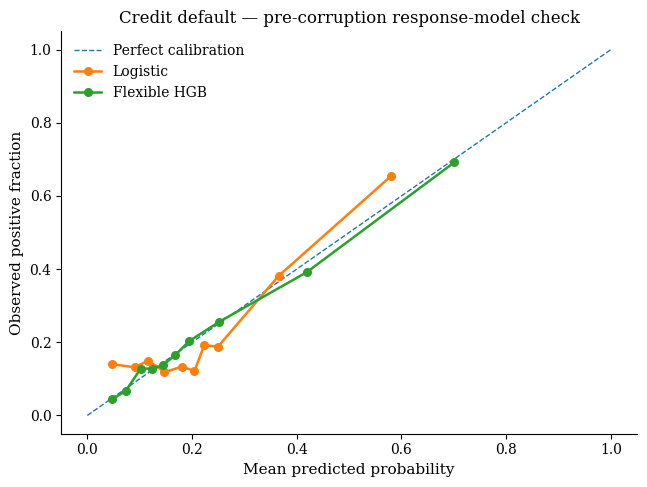

In [27]:
credit_pre_corruption_check = pre_corruption_response_check(
    X_train=Xc_model,
    y_train=yc_train,
    X_test=Xc_model_test,
    y_test=yc_test,
    dataset_label="Credit default",
    file_stem="highrep_credit",
    seed=SEED,
)

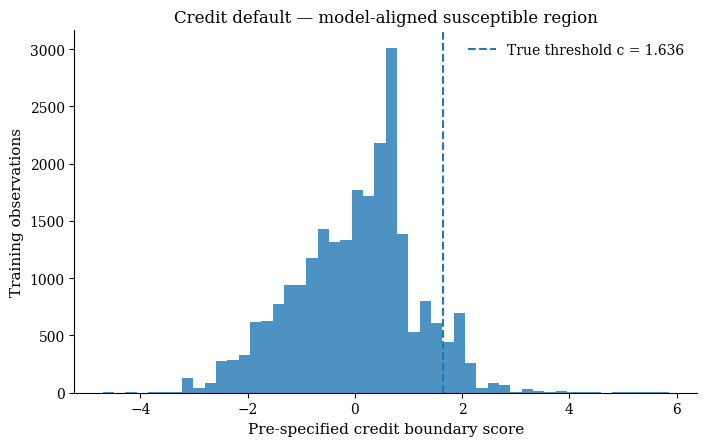

In [28]:
# Safe rerun: this output is redirected to the high-replication Chapter 2 folder.
fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.hist(
    Xc_model[:, 0],
    bins=50,
    alpha=0.8,
)

ax.axvline(
    C_C_TRUE,
    linestyle="--",
    linewidth=1.5,
    label=f"True threshold c = {C_C_TRUE:.3f}",
)

ax.set_title(
    "Credit default — model-aligned susceptible region"
)
ax.set_xlabel(
    "Pre-specified credit boundary score"
)
ax.set_ylabel(
    "Training observations"
)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig_ch2_credit_susceptible_region.pdf",
    bbox_inches="tight",
)

plt.savefig(
    FIG_DIR / "fig_ch2_credit_susceptible_region.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3.3 Matched Bayesian sample and localisation benchmark

In [29]:
idx_bayes_c = stratified_application_sample(
    Xc_model,
    yc_train,
    region_c,
    min(BAYES_N, len(yc_train)),
    SEED + 600,
)

Xc_bayes = Xc_model[
    idx_bayes_c
]

yc_bayes_true = yc_train[
    idx_bayes_c
]

region_c_bayes = region_c[
    idx_bayes_c
]

yc_bayes_obs, flips_c = corrupt_one_sided(
    yc_bayes_true,
    region_c_bayes,
    Q_APPLIED,
    np.random.default_rng(
        SEED + 601
    ),
)

display(
    pd.DataFrame([
        audit_corruption(
            yc_bayes_true,
            yc_bayes_obs,
            region_c_bayes,
            Q_APPLIED,
            "Credit Bayesian sample",
        )
    ])
)

cl_score_c = cleanlab_scores(
    Xc_bayes,
    yc_bayes_obs,
    seed=SEED + 602,
    folds=3,
)

cl_metrics_c = ranking_metrics(
    yc_bayes_obs,
    flips_c,
    cl_score_c,
)

display(
    pd.DataFrame([{
        "method": "Confident learning",
        **cl_metrics_c,
    }])
)

,dataset,n,q,region_share,eligible_positives,n_corrupted,effective_flip_rate,flips_1_to_0,flips_0_to_1,corruptions_outside_region
0,Credit Bayesian sample,6000,0.35,0.064333,272,92,0.015333,92,0,0


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Confident learning,4765,92,0.983999,0.456522


## 3.4 Credit axis-supplied Bayesian fit

In [30]:
stan_data_c = {
    "n": len(yc_bayes_obs),
    "p": Xc_bayes.shape[1],
    "X": Xc_bayes.tolist(),
    "y": yc_bayes_obs.astype(int).tolist(),
    "boundary_dim": 1,
    "kappa": KAPPA,
    "c_prior_mean": 0.0,
    "c_prior_sd": 1.5,
}

fit_c_axis = model_axis.sample(
    data=stan_data_c,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED + 700,
    adapt_delta=0.95,
    max_treedepth=12,
    show_progress=True,
)

diag_c_axis, core_c_axis = core_sampler_diagnostics(
    fit_c_axis
)

display(
    pd.DataFrame([
        diag_c_axis
    ])
)

c_draw_c = fit_c_axis.stan_variable(
    "c"
)
q_draw_c = fit_c_axis.stan_variable(
    "q"
)
z_c = fit_c_axis.stan_variable(
    "z_prob"
).mean(axis=0)

bayes_metrics_c_exploratory = ranking_metrics(
    yc_bayes_obs,
    flips_c,
    z_c,
)

credit_parameter_summary = pd.DataFrame([
    {
        "parameter": "c",
        "true": C_C_TRUE,
        "posterior_mean": c_draw_c.mean(),
        "ci_2.5": np.quantile(c_draw_c, 0.025),
        "ci_97.5": np.quantile(c_draw_c, 0.975),
    },
    {
        "parameter": "q",
        "true": Q_APPLIED,
        "posterior_mean": q_draw_c.mean(),
        "ci_2.5": np.quantile(q_draw_c, 0.025),
        "ci_97.5": np.quantile(q_draw_c, 0.975),
    },
])

if diag_c_axis["converged"]:
    bayes_metrics_c = bayes_metrics_c_exploratory
    display(pd.DataFrame([
        {"method": "Bayesian posterior", **bayes_metrics_c},
        {"method": "Confident learning", **cl_metrics_c},
    ]))
    display(credit_parameter_summary)
else:
    bayes_metrics_c = {
        "n_candidates": bayes_metrics_c_exploratory["n_candidates"],
        "n_corrupted": bayes_metrics_c_exploratory["n_corrupted"],
        "ranked_auc": np.nan,
        "precision_at_k": np.nan,
    }
    print(
        "CREDIT BAYESIAN FIT NOT INTERPRETED: diagnostics did not pass. "
        "Posterior recovery and localisation summaries below are retained only "
        "as exploratory outputs and are excluded from the main synthesis."
    )
    display(pd.DataFrame([
        {"method": "Bayesian posterior (exploratory; failed diagnostics)",
         **bayes_metrics_c_exploratory},
        {"method": "Confident learning", **cl_metrics_c},
    ]))
    display(credit_parameter_summary)


22:31:17 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

22:32:18 - cmdstanpy - INFO - CmdStan done processing.


,divergences,max_treedepth_hits,max_rhat,min_ess_bulk,converged
0,0,0,1.52934,7.12529,False


CREDIT BAYESIAN FIT NOT INTERPRETED: diagnostics did not pass. Posterior recovery and localisation summaries below are retained only as exploratory outputs and are excluded from the main synthesis.


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Bayesian posterior (exploratory; failed diagno...,4765,92,0.985688,0.456522
1,Confident learning,4765,92,0.983999,0.456522


,parameter,true,posterior_mean,ci_2.5,ci_97.5
0,c,1.635868,0.027490,-1.236902,2.767209
1,q,0.350000,0.360004,0.203471,0.675386


### Credit-fit interpretation

The Credit axis-supplied Bayesian fit is interpreted only if it passes the same sampler criteria used elsewhere in the notebook. A failed fit is itself an applied stability result: posterior means, intervals and localisation scores from that fit may be displayed for transparency, but they are not used as evidence of mechanism recovery or as a valid Bayesian-versus-confident-learning comparison.

The confident-learning benchmark does not depend on this MCMC fit and therefore remains interpretable on the matched corrupted sample.


## 3.4a Exploratory response-versus-geometry diagnostic

The Credit Bayesian fit fails the pre-specified convergence gate, so none of its
posterior summaries are used as inferential results. The calculations below are retained
only as an exploratory diagnostic of the same boundary-expansion pattern examined for
BRFSS. In particular, the response-only ranking is not promoted into the cross-domain
synthesis because it is derived from a non-converged fit.


In [31]:
# Exploratory only: the Credit posterior did not pass the convergence gate.
c_hat_c_exploratory = float(c_draw_c.mean())
r_fitted_c_exploratory = sigmoid(
    KAPPA * (Xc_bayes[:, 0] - c_hat_c_exploratory)
)

p_hat_c_exploratory = posterior_mean_response_probability(
    fit_c_axis,
    Xc_bayes,
)

response_only_metrics_c_exploratory = ranking_metrics(
    yc_bayes_obs,
    flips_c,
    p_hat_c_exploratory,
)

credit_response_geometry_exploratory = pd.DataFrame([{
    "diagnostic_status": "exploratory — Bayesian fit failed convergence gate",
    "c_true": C_C_TRUE,
    "c_hat": c_hat_c_exploratory,
    "boundary_score_min": float(Xc_bayes[:, 0].min()),
    "mean_fitted_membership": float(r_fitted_c_exploratory.mean()),
    "share_membership_gt_0.5": float(
        np.mean(r_fitted_c_exploratory > 0.5)
    ),
    "share_membership_gt_0.9": float(
        np.mean(r_fitted_c_exploratory > 0.9)
    ),
}])

credit_ranking_comparison_exploratory = pd.DataFrame([
    {
        "method": "Bayesian posterior (exploratory; failed diagnostics)",
        **bayes_metrics_c_exploratory,
    },
    {
        "method": "Response probability only (exploratory)",
        **response_only_metrics_c_exploratory,
    },
    {
        "method": "Confident learning",
        **cl_metrics_c,
    },
])

display(credit_response_geometry_exploratory)
display(credit_ranking_comparison_exploratory)

print(
    "Exploratory AUC difference, Bayesian posterior minus response-only:",
    bayes_metrics_c_exploratory["ranked_auc"]
    - response_only_metrics_c_exploratory["ranked_auc"],
)
print(
    "Reminder: the Credit Bayesian fit failed convergence diagnostics; "
    "these values diagnose behaviour but are not inferential results."
)


,diagnostic_status,c_true,c_hat,boundary_score_min,mean_fitted_membership,share_membership_gt_0.5,share_membership_gt_0.9
0,exploratory — Bayesian fit failed convergence ...,1.635868,0.02749,-4.704415,0.530378,0.538167,0.391167


,method,n_candidates,n_corrupted,ranked_auc,precision_at_k
0,Bayesian posterior (exploratory; failed diagno...,4765,92,0.985688,0.456522
1,Response probability only (exploratory),4765,92,0.985006,0.445652
2,Confident learning,4765,92,0.983999,0.456522


Exploratory AUC difference, Bayesian posterior minus response-only: 0.0006815284846343195
Reminder: the Credit Bayesian fit failed convergence diagnostics; these values diagnose behaviour but are not inferential results.


# 4. Cross-domain synthesis

The applied synthesis distinguishes four related but different questions:

- **mechanism recovery** — are the known \(c\) and \(q\) values recovered?
- **predictive robustness** — does clean-test AUC degrade materially under the injected corruption?
- **localisation** — can the known corrupted observations be ranked above clean observed negatives?
- **posterior stability** — do the sampler diagnostics support interpretation of the fitted mechanism?

The BRFSS specification diagnostics are part of the substantive analysis rather than debugging residue. They test whether recovery changes when threshold uncertainty is removed or when the realistic covariates are paired with a response generated from the assumed logistic model. These comparisons are used diagnostically and are not treated as a formal proof of a unique cause of recovery failure.


,domain,n_bayes,region_share,n_corrupted,effective_flip_rate,bayes_ranked_auc,bayes_precision_at_k,cl_ranked_auc,cl_precision_at_k,axis_fit_passed,c_error_main,q_error_main,q_error_fixed_c,c_error_model_correct_y,q_error_model_correct_y
0,BRFSS,6000,0.096833,76,0.012667,0.950387,0.263158,0.935114,0.263158,True,3.730279,0.307965,0.237846,0.194147,0.009614
1,Credit default,6000,0.064333,92,0.015333,NaN,NaN,0.983999,0.456522,False,NaN,NaN,NaN,NaN,NaN


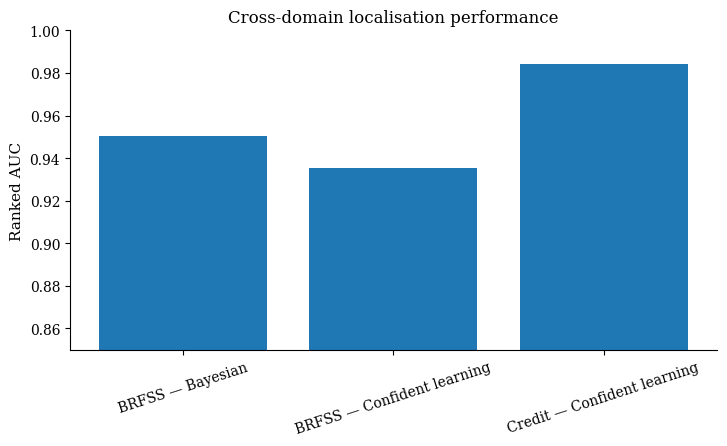

In [32]:
# Safe rerun: this output is redirected to the high-replication Chapter 2 folder.
summary_rows = []

summary_rows.append({
    "domain": "BRFSS",
    "n_bayes": len(yb_bayes_obs),
    "region_share": region_b_bayes.mean(),
    "n_corrupted": int(flips_b.sum()),
    "effective_flip_rate": flips_b.mean(),
    "bayes_ranked_auc": bayes_metrics_b["ranked_auc"],
    "bayes_precision_at_k": bayes_metrics_b["precision_at_k"],
    "cl_ranked_auc": cl_metrics_b["ranked_auc"],
    "cl_precision_at_k": cl_metrics_b["precision_at_k"],
    "axis_fit_passed": diag_b_axis["converged"],
    "c_error_main": abs(
        c_draw.mean()
        - C_B_TRUE
    ),
    "q_error_main": abs(
        q_draw.mean()
        - Q_APPLIED
    ),
    "q_error_fixed_c": abs(
        q_fixed_c.mean()
        - Q_APPLIED
    ),
    "c_error_model_correct_y": abs(
        c_mc.mean()
        - C_B_TRUE
    ),
    "q_error_model_correct_y": abs(
        q_mc.mean()
        - Q_APPLIED
    ),
})

summary_rows.append({
    "domain": "Credit default",
    "n_bayes": len(yc_bayes_obs),
    "region_share": region_c_bayes.mean(),
    "n_corrupted": int(flips_c.sum()),
    "effective_flip_rate": flips_c.mean(),
    "bayes_ranked_auc": (
        bayes_metrics_c["ranked_auc"]
        if diag_c_axis["converged"]
        else np.nan
    ),
    "bayes_precision_at_k": (
        bayes_metrics_c["precision_at_k"]
        if diag_c_axis["converged"]
        else np.nan
    ),
    "cl_ranked_auc": cl_metrics_c["ranked_auc"],
    "cl_precision_at_k": cl_metrics_c["precision_at_k"],
    "axis_fit_passed": diag_c_axis["converged"],
    "c_error_main": (
        abs(c_draw_c.mean() - C_C_TRUE)
        if diag_c_axis["converged"]
        else np.nan
    ),
    "q_error_main": (
        abs(q_draw_c.mean() - Q_APPLIED)
        if diag_c_axis["converged"]
        else np.nan
    ),
    "q_error_fixed_c": np.nan,
    "c_error_model_correct_y": np.nan,
    "q_error_model_correct_y": np.nan,
})

application_summary = pd.DataFrame(
    summary_rows
)

display(
    application_summary
)

application_summary.to_csv(
    RESULT_DIR / "highrep_chapter2_application_summary.csv",
    index=False
)

# Cross-domain localisation summary.
# Bayesian values are shown only for fits that passed diagnostics.
plot_rows = [
    {
        "domain_method": "BRFSS — Bayesian",
        "ranked_auc": bayes_metrics_b["ranked_auc"],
    },
    {
        "domain_method": "BRFSS — Confident learning",
        "ranked_auc": cl_metrics_b["ranked_auc"],
    },
    {
        "domain_method": "Credit — Confident learning",
        "ranked_auc": cl_metrics_c["ranked_auc"],
    },
]

if diag_c_axis["converged"]:
    plot_rows.append({
        "domain_method": "Credit — Bayesian",
        "ranked_auc": bayes_metrics_c["ranked_auc"],
    })

localisation_plot = pd.DataFrame(plot_rows)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.bar(
    localisation_plot["domain_method"],
    localisation_plot["ranked_auc"],
)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("Ranked AUC")
ax.set_title("Cross-domain localisation performance")
ax.tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "fig_ch2_cross_domain_localisation_valid_fits.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "fig_ch2_cross_domain_localisation_valid_fits.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 5. Chapter 2 conclusions to write from the executed outputs

### RQ1 — Mechanism recoverability
Report recovery of the known threshold \(c\) and corruption probability \(q\),
with posterior intervals and sampler diagnostics. Keep this distinct from
predictive robustness. For the full-training-set corruption sweep, report
realised corruption counts and effective global flip rates alongside nominal
\(q\).

### RQ2 — Localisation
Compare the Bayesian posterior and confident learning on the same
observed-negative candidate set using ranked AUC and precision@\(\,k\), but
only interpret Bayesian localisation when the corresponding MCMC fit passes
diagnostics. In Credit, retain confident learning as the valid localisation
benchmark if the Bayesian fit fails.

### RQ3 — Individual uncertainty
Assess whether genuinely injected corruptions receive larger posterior
corruption probabilities than clean observed negatives, and use the
individual-level table only as a semi-synthetic validation device.

### Predictive robustness
Interpret a small clean-test AUC drop as robustness of global discrimination
to the injected local corruption. It is not evidence that the corruption
mechanism is absent or identifiable.

### Pre-corruption response-model checks
Before interpreting recovery after label poisoning, report the clean held-out
logistic calibration/Brier/log-loss diagnostics and compare the logistic
response surface with the flexible HGB benchmark. A flexible-model advantage
is evidence of response-model misspecification to be considered in the later
mechanism-recovery interpretation; it is not itself a test of the corruption
model.

### Specification diagnostics
Separate MCMC convergence from scientific recovery. Use the fixed-\(c\) and
model-correct-\(Y\) fits to assess how recovery changes when threshold
uncertainty or response-model mismatch is reduced. Do not claim that either
diagnostic uniquely identifies the cause of failure.

### General boundary
Interpret the estimated \(\alpha\) only if the general-model fit passes the
same diagnostic criteria used in Chapter 1. A diagnostic failure remains an
applied result.

### Scope
The semi-synthetic design validates recovery and localisation of a known
injected mechanism on realistic feature distributions. It does not estimate
naturally occurring undiagnosed diabetes or hidden financial distress.

### Main high-replication outputs saved by this notebook

Outputs are written under `high_replication/chapter2/`.

Key figures include:

- `figures/highrep_brfss_pre_corruption_response_check.pdf`
- `figures/highrep_fig_ch2_brfss_predictive_sensitivity.pdf`
- `figures/highrep_fig_ch2_brfss_predictive_stability.pdf`
- `figures/fig_ch2_brfss_posterior_corruption_probabilities.pdf`
- `figures/fig_ch2_brfss_recovery_diagnostics.pdf`
- `figures/fig_ch2_brfss_threshold_recovery.pdf`
- `figures/highrep_credit_pre_corruption_response_check.pdf`
- `figures/fig_ch2_cross_domain_localisation_valid_fits.pdf`

The cross-domain plot deliberately excludes a Bayesian Credit bar when that
fit fails diagnostics.